# MOYENS D'AUGMENTER LA PUISSANCE STATISTIQUE D'UN TEST

## Objectif du notebook

Ce notebook transforme le concept EBTA en outil visuel et quantitatif.

On veut comprendre pourquoi certains tests statistiques échouent à détecter un **edge réel** même quand cet edge existe.

> La **puissance statistique** est la capacité d'un test à rejeter $H_0$ lorsque $H_0$ est réellement fausse.

Dans le langage du trading :

> Un test puissant voit plus facilement la différence entre une stratégie réellement profitable et une stratégie simplement chanceuse.

---

## 1. Intuition centrale

Dans les travaux de David Aronson, la question n'est pas seulement :

> “Est-ce que ma stratégie a fait du profit en backtest ?”

La vraie question est :

> “Est-ce que le profit observé est assez clair pour être distingué du hasard ?”

Un test manque de puissance quand le **bruit statistique** est trop large par rapport au **signal réel**.

La puissance augmente principalement quand :

| Levier | Effet sur le test | Lecture trading |
|---|---:|---|
| Augmenter $N$ | Réduit l'incertitude | Plus de trades, plus de clarté |
| Réduire la variance | Réduit le bruit | Résultats moins erratiques |
| Tester moins de règles inutiles | Réduit la pénalité de sélection | Moins de data-mining aveugle |
| Chercher un edge plus fort | Augmente le signal | Le mérite se détache mieux du bruit |

---

## 2. Formule clé : l'erreur standard

La dispersion de la distribution d'échantillonnage dépend de deux éléments :

$$
SE = \frac{\sigma}{\sqrt{N}}
$$

Avec :

- $SE$ : **erreur standard**, c'est-à-dire l'incertitude autour de la moyenne observée.
- $\sigma$ : volatilité ou dispersion des rendements.
- $N$ : nombre d'observations, par exemple nombre de trades.

Conséquence directe :

> Si on multiplie $N$ par $100$, on divise l'incertitude par $10$.

Mais attention :

> Pour diviser l'incertitude par $2$, il faut multiplier les données par $4$.

C'est le principe des **rendements décroissants** de l'information statistique.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
from scipy import stats

np.random.seed(42)

# Paramètres pédagogiques
true_edge = 0.10      # Edge moyen réel par trade, en R
sigma = 1.00          # Bruit par trade, en R
sample_sizes = [20, 50, 100, 200, 600, 1000]

rows = []
for n in sample_sizes:
    se = sigma / np.sqrt(n)
    signal_noise_ratio = true_edge / se
    rows.append({
        "N trades": n,
        "Erreur standard": se,
        "Signal / Bruit": signal_noise_ratio,
        "IC 95% approx. ±": 1.96 * se
    })

df_power_intuition = pd.DataFrame(rows)
df_power_intuition

,N trades,Erreur standard,Signal / Bruit,IC 95% approx. ±
0,20,0.223607,0.447214,0.438269
1,50,0.141421,0.707107,0.277186
2,100,0.100000,1.000000,0.196000
3,200,0.070711,1.414214,0.138593
4,600,0.040825,2.449490,0.080017
5,1000,0.031623,3.162278,0.061981


## 3. Visualiser l'effet de $N$

On va simuler plusieurs distributions d'échantillonnage.

Chaque distribution représente ce que l'on pourrait observer comme **moyenne de performance** si une stratégie avait un vrai edge moyen de $0.10R$ par trade.

Plus $N$ augmente, plus la distribution devient étroite.

---

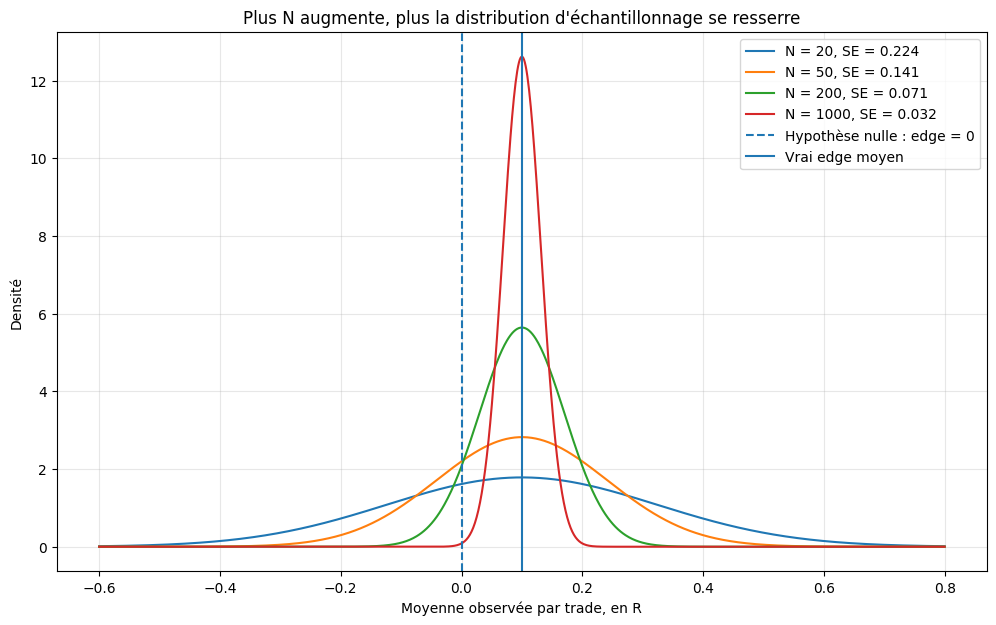

In [2]:
x = np.linspace(-0.6, 0.8, 1000)

plt.figure(figsize=(12, 7))

for n in [20, 50, 200, 1000]:
    se = sigma / np.sqrt(n)
    y = stats.norm.pdf(x, loc=true_edge, scale=se)
    plt.plot(x, y, label=f"N = {n}, SE = {se:.3f}")

plt.axvline(0, linestyle="--", label="Hypothèse nulle : edge = 0")
plt.axvline(true_edge, linestyle="-", label="Vrai edge moyen")
plt.title("Plus N augmente, plus la distribution d'échantillonnage se resserre")
plt.xlabel("Moyenne observée par trade, en R")
plt.ylabel("Densité")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Lecture trading

Avec peu de trades, une stratégie ayant un vrai edge peut facilement ressembler à une stratégie sans edge.

Pourquoi ?

Parce que sa moyenne observée peut encore beaucoup varier à cause du hasard.

Avec beaucoup de trades, l'incertitude diminue. Le même edge devient plus facile à détecter.

> Le rôle de $N$ n'est pas de rendre une stratégie meilleure.  
> Le rôle de $N$ est de rendre la mesure de son mérite plus précise.

---

## 5. Puissance statistique et erreur de Type II

Une **Erreur de Type II** se produit quand on ne rejette pas $H_0$ alors que $H_0$ est fausse.

Dans notre cas :

$$
H_0 : \mu = 0
$$

$$
H_1 : \mu > 0
$$

En trading :

- $H_0$ : la stratégie n'a aucun edge.
- $H_1$ : la stratégie a un edge positif.
- Erreur de Type II : abandonner une stratégie qui avait réellement du mérite.

La puissance vaut :

$$
\text{Puissance} = 1 - \beta
$$

où $\beta$ est la probabilité de faire une **Erreur de Type II**.

---

In [3]:
def one_sided_power(effect, sigma, n, alpha=0.05):
    """Puissance d'un test unilatéral à droite pour une moyenne normale connue approximativement."""
    se = sigma / np.sqrt(n)
    critical_value = stats.norm.ppf(1 - alpha, loc=0, scale=se)
    power = 1 - stats.norm.cdf(critical_value, loc=effect, scale=se)
    return critical_value, power

power_rows = []
for n in sample_sizes:
    critical_value, power = one_sided_power(true_edge, sigma, n)
    power_rows.append({
        "N trades": n,
        "Seuil critique alpha 5%": critical_value,
        "Puissance": power,
        "Risque Type II beta": 1 - power
    })

df_power = pd.DataFrame(power_rows)
df_power

,N trades,Seuil critique alpha 5%,Puissance,Risque Type II beta
0,20,0.367800,0.115529,0.884471
1,50,0.232617,0.174187,0.825813
2,100,0.164485,0.259511,0.740489
3,200,0.116309,0.408797,0.591203
4,600,0.067151,0.789485,0.210515
5,1000,0.052015,0.935420,0.064580


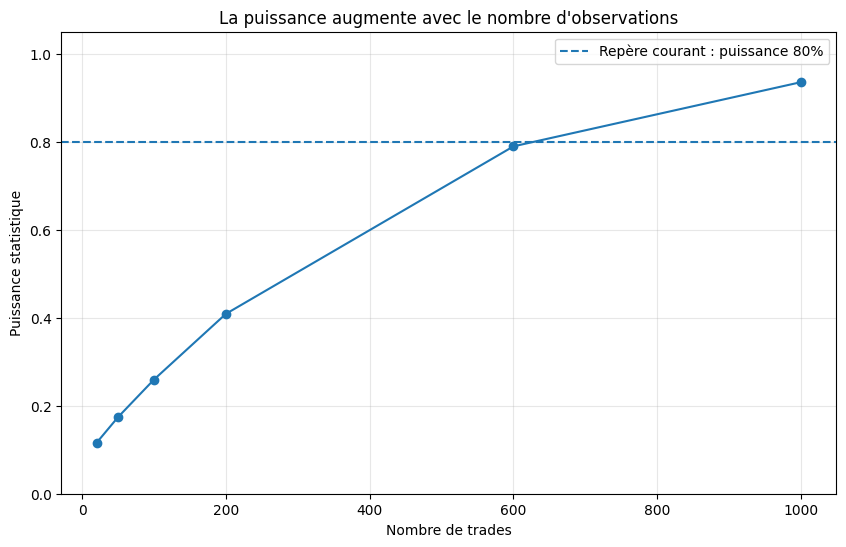

In [4]:
plt.figure(figsize=(10, 6))

plt.plot(df_power["N trades"], df_power["Puissance"], marker="o")
plt.axhline(0.80, linestyle="--", label="Repère courant : puissance 80%")
plt.title("La puissance augmente avec le nombre d'observations")
plt.xlabel("Nombre de trades")
plt.ylabel("Puissance statistique")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 6. Effet de la variance : même edge, bruit différent

Deux stratégies peuvent avoir le même rendement moyen attendu, mais pas la même facilité de validation.

Une stratégie très volatile produit une distribution d'échantillonnage plus large.

Donc, même si son edge existe, il sera plus difficile à prouver.

> Ce n'est pas seulement la taille du profit moyen qui compte.  
> C'est le rapport entre le profit moyen et le bruit.

---

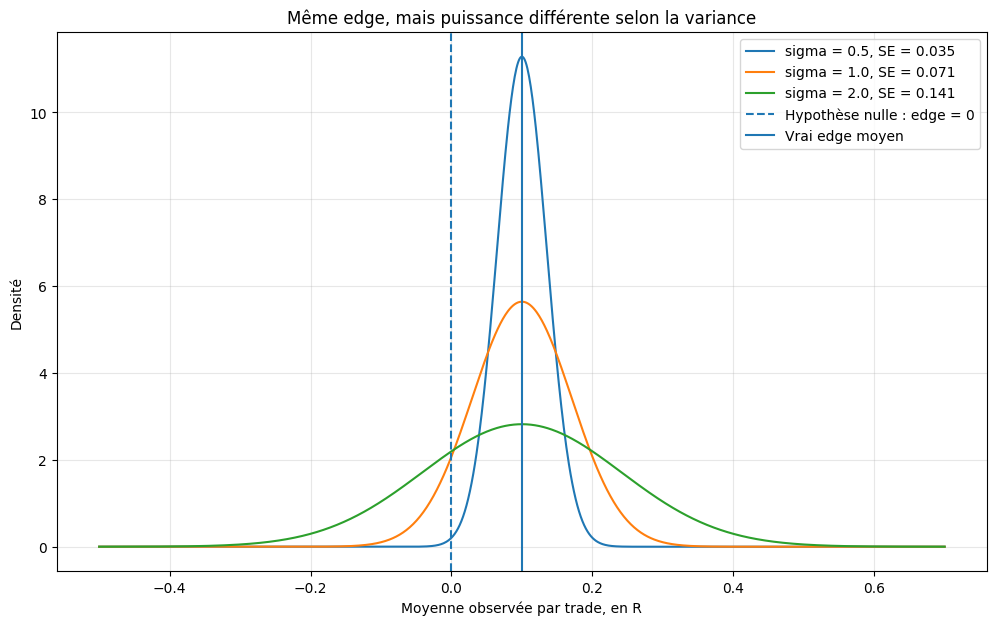

In [5]:
sigma_values = [0.5, 1.0, 2.0]
n = 200
x = np.linspace(-0.5, 0.7, 1000)

plt.figure(figsize=(12, 7))

for s in sigma_values:
    se = s / np.sqrt(n)
    y = stats.norm.pdf(x, loc=true_edge, scale=se)
    plt.plot(x, y, label=f"sigma = {s}, SE = {se:.3f}")

plt.axvline(0, linestyle="--", label="Hypothèse nulle : edge = 0")
plt.axvline(true_edge, linestyle="-", label="Vrai edge moyen")
plt.title("Même edge, mais puissance différente selon la variance")
plt.xlabel("Moyenne observée par trade, en R")
plt.ylabel("Densité")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Effet du data-mining : trop de règles testées

Dans un univers de minage, on ne teste pas une seule règle.

On teste souvent des dizaines, centaines ou milliers de variantes :

- paramètres différents ;
- timeframes différents ;
- filtres différents ;
- actifs différents ;
- règles d'entrée et de sortie combinées.

Plus on teste de règles, plus le hasard a de chances de produire une fausse “meilleure stratégie”.

C'est le problème des **comparaisons multiples**.

---

In [6]:
np.random.seed(123)

def simulate_best_random_strategy(n_rules, n_trades=200, sigma=1.0, n_simulations=5000):
    """Simule le meilleur résultat obtenu par hasard parmi n_rules règles sans edge."""
    # Chaque règle a une moyenne observée issue d'un monde où le vrai edge vaut 0
    se = sigma / np.sqrt(n_trades)
    random_means = np.random.normal(loc=0, scale=se, size=(n_simulations, n_rules))
    best_means = random_means.max(axis=1)
    return best_means

rule_counts = [1, 10, 100, 1000]
best_results = {}

for n_rules in rule_counts:
    best_results[n_rules] = simulate_best_random_strategy(n_rules)

summary_rows = []
for n_rules, values in best_results.items():
    summary_rows.append({
        "Nombre de règles testées": n_rules,
        "Meilleur résultat moyen par hasard": np.mean(values),
        "Quantile 95% du meilleur hasard": np.quantile(values, 0.95),
        "Quantile 99% du meilleur hasard": np.quantile(values, 0.99)
    })

df_mining = pd.DataFrame(summary_rows)
df_mining

,Nombre de règles testées,Meilleur résultat moyen par hasard,Quantile 95% du meilleur hasard,Quantile 99% du meilleur hasard
0,1,0.001491,0.116121,0.163143
1,10,0.109669,0.182015,0.219090
2,100,0.177582,0.231400,0.264079
3,1000,0.228737,0.273195,0.301153


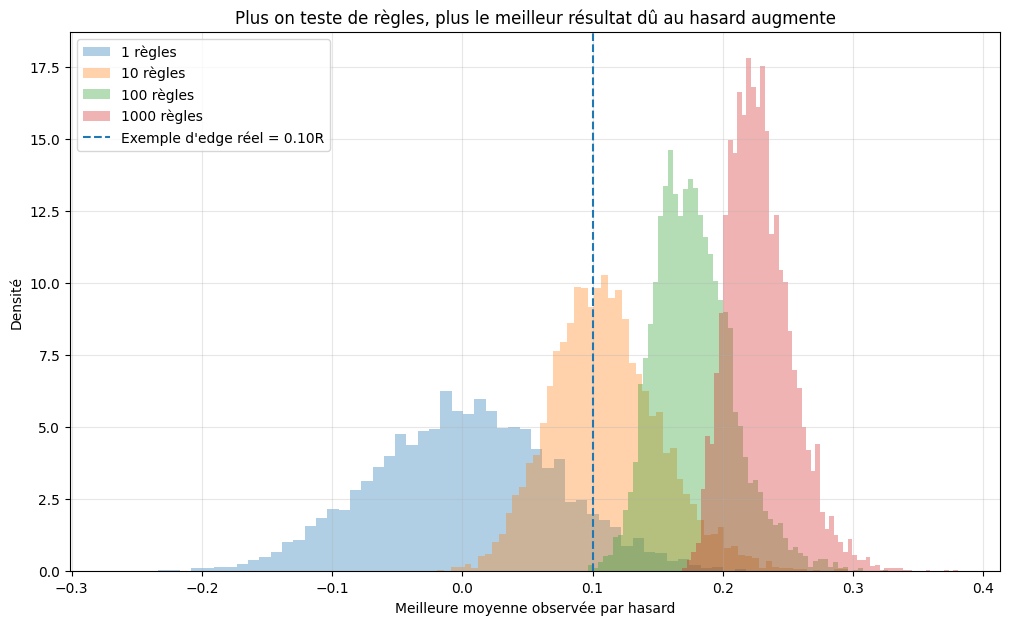

In [7]:
plt.figure(figsize=(12, 7))

for n_rules, values in best_results.items():
    plt.hist(values, bins=60, density=True, alpha=0.35, label=f"{n_rules} règles")

plt.axvline(true_edge, linestyle="--", label="Exemple d'edge réel = 0.10R")
plt.title("Plus on teste de règles, plus le meilleur résultat dû au hasard augmente")
plt.xlabel("Meilleure moyenne observée par hasard")
plt.ylabel("Densité")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Lecture EBTA de l'univers de minage

Ce graphique montre pourquoi la composition de l'univers est essentielle.

Si l'on inclut énormément de règles médiocres ou absurdes, on augmente les opportunités offertes au hasard.

Dans les tests comme le **White's Reality Check** ou la **MCPM**, cela peut rendre le seuil de significativité plus difficile à franchir.

L'amélioration de **Romano-Wolf** répond précisément à une faiblesse : certaines règles très mauvaises peuvent réduire la puissance du test global en gonflant inutilement la correction.

> Nettoyer l'univers de recherche n'est pas tricher.  
> C'est éviter de demander au test de corriger un chaos que l'on a soi-même créé.

---

## 9. Exemple synthétique : quatre leviers de puissance

On peut résumer la puissance comme une équation qualitative :

| Levier | Effet | Action concrète |
|---|---|---|
| Plus d'observations | Réduit l'erreur standard | Tester sur plus de trades ou plus d'années |
| Moins de variance | Réduit le bruit | Normaliser le risque, filtrer les régimes extrêmes |
| Moins de règles poubelles | Réduit la pénalité de data-mining | Pré-filtrer avec une logique économique |
| Edge plus fort | Augmente le signal | Partir d'une hypothèse plausible, pas d'une recherche aveugle |

---

In [8]:
# Mini-dashboard pédagogique

scenarios = pd.DataFrame({
    "Scenario": [
        "Peu de trades, bruit élevé",
        "Plus de trades",
        "Plus de trades + bruit réduit",
        "Plus de trades + bruit réduit + edge fort"
    ],
    "Edge moyen": [0.10, 0.10, 0.10, 0.20],
    "Sigma": [1.5, 1.5, 0.8, 0.8],
    "N trades": [50, 500, 500, 500]
})

powers = []
for _, row in scenarios.iterrows():
    _, pwr = one_sided_power(
        effect=row["Edge moyen"],
        sigma=row["Sigma"],
        n=int(row["N trades"]),
        alpha=0.05
    )
    powers.append(pwr)

scenarios["Puissance"] = powers
scenarios["Erreur Type II"] = 1 - scenarios["Puissance"]
scenarios

,Scenario,Edge moyen,Sigma,N trades,Puissance,Erreur Type II
0,"Peu de trades, bruit élevé",0.1,1.5,50,0.120308,0.879692
1,Plus de trades,0.1,1.5,500,0.438749,0.561251
2,Plus de trades + bruit réduit,0.1,0.8,500,0.874976,0.125024
3,Plus de trades + bruit réduit + edge fort,0.2,0.8,500,0.999960,0.000040


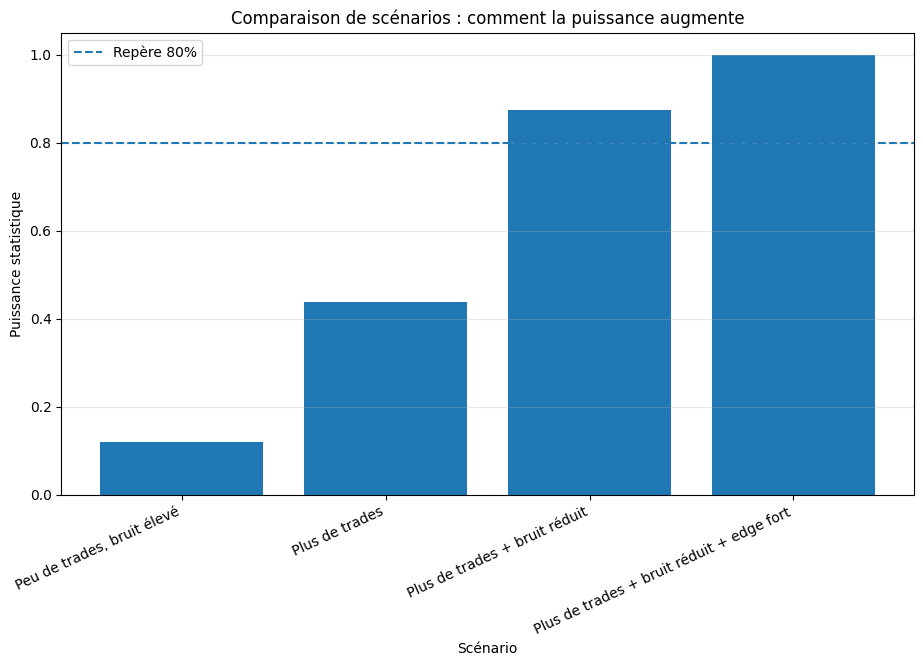

In [9]:
plt.figure(figsize=(11, 6))

plt.bar(scenarios["Scenario"], scenarios["Puissance"])
plt.axhline(0.80, linestyle="--", label="Repère 80%")
plt.title("Comparaison de scénarios : comment la puissance augmente")
plt.xlabel("Scénario")
plt.ylabel("Puissance statistique")
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.show()

## 10. Erreurs fréquentes

### Erreur 1 : confondre puissance et profit

La **puissance** n'est pas le profit.

La puissance mesure la capacité du test à voir un profit réel s'il existe.

Une stratégie peut être profitable mais difficile à valider si :

- elle a peu de trades ;
- elle est très volatile ;
- son edge est petit ;
- elle a été découverte dans un énorme univers de règles.

### Erreur 2 : croire qu'un test sophistiqué compense le manque de données

Un meilleur test peut réduire certains biais.

Mais il ne peut pas créer de l'information.

> Aucun test statistique ne transforme un historique trop court et trop bruité en preuve robuste.

### Erreur 3 : ajouter des règles sans logique

Plus l'univers de recherche est large, plus la sélection devient dangereuse.

Un univers de règles doit être construit avec une logique théorique ou empirique claire.

---

## 11. Checklist EBTA pour augmenter la puissance

Avant de conclure qu'une stratégie n'a pas d'edge, vérifier :

| Question | Pourquoi c'est important |
|---|---|
| Ai-je assez d'observations ? | Trop peu de trades = test sourd |
| La variance des rendements est-elle énorme ? | Bruit élevé = edge difficile à voir |
| Ai-je testé trop de variantes ? | Comparaisons multiples = seuil plus dur |
| La règle a-t-elle une logique plausible ? | Signal plus fort dès le départ |
| Ai-je séparé puissance et rentabilité ? | Une bonne règle peut être rejetée par manque de données |

---

## 12. Eurêka final

> La puissance statistique est la résolution du microscope.

Un test peu puissant regarde une stratégie réelle à travers une vitre floue.

Il peut voir un edge et croire que c'est du hasard.

Dans l'esprit EBTA, augmenter la puissance revient à réduire le flou :

- plus de données ;
- moins de bruit ;
- moins de règles inutiles ;
- meilleurs candidats dès le départ.

> Le trader scientifique ne cherche pas seulement un bon backtest.  
> Il cherche une preuve assez nette pour survivre au hasard.

---

## Annexe — Texte source fourni

D'après les travaux de David Aronson, l'amélioration de Romano-Wolf est une solution technique spécifique pour corriger une perte de puissance liée à la composition de l'univers de minage (critique de Hansen). Cependant, le livre identifie d'autres leviers fondamentaux, plus structurels, pour augmenter la puissance statistique d'un test.

# MOYENS D'AUGMENTER LA PUISSANCE STATISTIQUE D'UN TEST

## Référence
*   **Titre :** *Statistical Analysis* (Chapitre 4) ; *Hypothesis Tests and Confidence Intervals* (Chapitre 5) ; *Data-Mining Bias* (Chapitre 6).
*   **Pages :** 176, 179, 299-301, 329-330.
*   **Thème principal :** Les facteurs influençant la dispersion de la distribution d'échantillonnage et la capacité de détection du mérite réel.

## Idées clés
1.  **L'augmentation de la taille de l'échantillon ($N$)** — C'est le levier le plus puissant. Un $N$ plus élevé rétrécit la distribution d'échantillonnage, rendant le test plus sensible aux petits avantages prédictifs. (Pages 179, 301).
2.  **La réduction de la variance de la population** — Moins les données de base sont volatiles, plus la distribution d'échantillonnage est étroite, ce qui augmente la puissance du test. (Page 181/Source).
3.  **La gestion de la composition de l'univers** — Éviter d'inclure des milliers de règles "pires que le hasard" (règles négatives) qui, sans Romano-Wolf, "gonflent" artificiellement le seuil de significativité. (Page 329).
4.  **Le choix de règles à fort mérite** — Une règle possédant un avantage prédictif réel important est plus facile à détecter, car elle s'éloignera plus nettement de la moyenne du hasard. (Page 282).

## Citation directe
> « Large samples give F-G, the truth that we wish to know, the ability to reveal itself. This is an effect of the Law of Large Numbers: Large samples reduce the role of chance. » (Page 179).
*(En français : Les grands échantillons donnent à la vérité la capacité de se révéler. C'est l'effet de la Loi des Grands Nombres : les grands échantillons réduisent le rôle du hasard.)*

## Vision macro
L'enjeu de la puissance statistique est d'éviter l'**Erreur de Type II** : rejeter une règle qui a pourtant un vrai talent parce que le test est trop "sourd" pour le percevoir. Pour Aronson, la puissance n'est pas seulement une affaire d'algorithme (comme Romano-Wolf), c'est une question de **résolution** : plus vous avez de données ($N$), plus votre "télescope" statistique est précis pour distinguer une étoile (un edge) d'un simple reflet (le bruit).

## Vision micro
Le fonctionnement de la puissance repose sur la **dispersion de la distribution d'échantillonnage** :

1.  **Mécanisme de l'échantillon ($N$) :** La largeur de la cloche de Gauss est inversement proportionnelle à la racine carrée de $N$. Si vous multipliez le nombre de trades par 100, vous divisez l'incertitude (et donc la zone d'ombre où le talent est confondu avec la chance) par 10.
2.  **Rapport Signal/Bruit :** La puissance augmente si l'effet que vous cherchez (le rendement attendu) est large par rapport à la variance des rendements.
3.  **Impact de la sélection (Multiple Comparisons) :** Sans Romano-Wolf, le simple fait d'augmenter le nombre de règles testées ($N$ rules) *diminue* la puissance effective du test sur chaque règle individuelle, car le seuil de réussite (p-value) devient extrêmement difficile à atteindre pour compenser le biais de minage.

## Exemples du livre
*   **L'expérience des 200 perles :** Aronson montre qu'avec un échantillon de 20 perles, l'incertitude est grande. En passant à 200 perles, la variation aléatoire devient trois fois plus petite, permettant de voir la "vérité" (la proportion réelle de perles grises) avec beaucoup plus de clarté.
*   **Le violoniste de l'orchestre :** Dans une audition de musique (faible hasard), le mérite est si évident que le "test" (l'écoute) a une puissance maximale immédiatement. En trading (fort hasard), il faut des centaines d'épreuves pour atteindre la même puissance de détection.

## Résumé simplifié
Pour rendre un test plus puissant sans changer de méthode mathématique, il faut lui donner "plus à manger". Le moyen le plus simple est d'utiliser beaucoup plus de données (plus de jours, plus de trades). C'est comme passer d'une photo floue à une photo HD : les détails (votre profit réel) deviennent visibles alors qu'ils étaient cachés dans le flou du hasard.

## Actions concrètes
*   **Ce qu'il faut faire :** Prioriser l'augmentation du nombre d'observations ($N$) avant toute chose.
*   **Ce qu'il faut éviter :** Tester des stratégies sur des historiques trop courts (moins de 200-600 points), car même avec Romano-Wolf, le test manquera de puissance pour valider un edge réel.
*   **Ce qu'il faut mesurer :** La réduction de l'écart-type de votre distribution d'échantillonnage à mesure que vous ajoutez des données.
*   **Ce qu'il faut tester :** Des règles simples basées sur des théories plausibles (Chapitre 7) pour maximiser les chances d'avoir un "signal" fort dès le départ.

## Limites et erreurs fréquentes
### Limites
*   **Le livre ne traite pas** d'autres algorithmes de tests multiples concurrents de Romano-Wolf (comme le False Discovery Rate) ; il se concentre sur le WRC et la MCPM.
*   L'augmentation de $N$ a des **rendements décroissants** : il faut quadrupler les données pour doubler la précision.

### Erreurs fréquentes
*   Confondre la **puissance du test** (capacité à voir le talent) avec le **profit de la règle** (le talent lui-même).
*   Croire que l'on peut compenser un manque de données par un test statistique ultra-sophistiqué. **Aucun test ne peut créer de l'information là où il n'y a que du bruit**.

## À retenir absolument
*   **$N$ (Observations) est le levier n°1** de la puissance.
*   La puissance est la capacité à **débusquer l'or réel** caché sous le hasard.
*   L'incertitude diminue quand la **taille de l'échantillon augmente**.
*   Inclure trop de "règles poubelles" dans un univers de minage **étouffe la puissance** du test.
*   Un test sans puissance vous fera **abandonner de bonnes stratégies** par erreur.

J'ai terminé l'analyse des moyens d'augmenter la puissance d'un test selon le protocole EBTA.